In [16]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat
import tensorflow as tf
import random as rn
from sklearn.metrics import accuracy_score, precision_score, recall_score, log_loss,f1_score, balanced_accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from scipy import signal
from skimage.transform import resize
# Reproducibility
sd = 1
os.environ['PYTHONHASHSEED'] = str(sd)
np.random.seed(sd)
rn.seed(sd)
tf.random.set_seed(sd)

# Root directory containing data folders
root_dir = './Paderborn_PreCase1_Data'

# Class label structure
data_structure = {
    0: ("Healthy", ["K001", "K002", "K003", "K004", "K005"]),
    1: ("OR_Damage", ["KA04", "KA15", "KA16", "KA22", "KA30"]),
    2: ("IR_Damage", ["KI04", "KI14", "KI16", "KI18", "KI21"]),
}

sample_limit_per_label = {0: 256000, 1: 5120, 2: 5120}

# Extract vibration signal from .mat file
def extract_signals_df(filepath, signal="vibration"):
    signals = {"vibration": 6, "current_1": 1, "current_2": 2}
    mat = loadmat(filepath, struct_as_record=False, squeeze_me=True)
    field = next(k for k in mat if not k.startswith("__"))
    struct = mat[field]
    X_channels = struct.X
    Y_channels = struct.Y
    v = Y_channels[signals["vibration"]].Data.flatten().reshape(-1, 1)
    return pd.DataFrame(v, columns=["vibration"])

# Data extraction
all_data = {0: [], 1: [], 2: []}

for label, (category, folders) in data_structure.items():
    for folder in folders:
        folder_path = os.path.join(root_dir, folder)
        if not os.path.exists(folder_path):
            print(f"Warning: Folder {folder_path} not found.")
            continue

        mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
        if not mat_files:
            print(f"No .mat files found in {folder_path}")
            continue

        filename = mat_files[0]
        file_path = os.path.join(folder_path, filename)
        try:
            df = extract_signals_df(file_path, signal="vibration")
            df = df.iloc[:sample_limit_per_label[label]].copy()
            df["label"] = label
            all_data[label].append(df)
            print(f"Loaded {file_path} with {len(df)} samples.")
        except Exception as e:
            print(f"Error reading {file_path}: {e}")

# Combine all data
final_df = pd.concat([df for dfs in all_data.values() for df in dfs], ignore_index=True)
final_df.rename(columns={"vibration": "signal"}, inplace=True)
print("\nCombined data shape:", final_df.shape)
print(final_df.head())

# Signal grouping
df_signals = final_df[["signal", "label"]].copy()
grouped_signals = [
    df_signals[df_signals['label'] == i]['signal'].values.astype(float)
    for i in sorted(df_signals['label'].unique())
]



# Datapoints per group
# print("\n Count of samples in each group")
for idx, signal_array in enumerate(grouped_signals):
    class_name = data_structure[idx][0]
    print(f"Class {idx} ({class_name}) - Number of samples: {len(signal_array)}")


Loaded ./Paderborn_PreCase1_Data/K001/N15_M07_F04_K001_13.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K002/N09_M07_F10_K002_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K003/N09_M07_F10_K003_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K004/N09_M07_F10_K004_2.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/K005/N09_M07_F10_K005_1.mat with 256000 samples.
Loaded ./Paderborn_PreCase1_Data/KA04/N09_M07_F10_KA04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA15/N09_M07_F10_KA15_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA16/N09_M07_F10_KA16_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA22/N09_M07_F10_KA22_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KA30/N09_M07_F10_KA30_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI04/N09_M07_F10_KI04_1.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_Data/KI14/N09_M07_F10_KI14_2.mat with 5120 samples.
Loaded ./Paderborn_PreCase1_D

In [17]:

# Data preparation
def Sampling(Data, interval_length, samples_per_block, ignore_points=0):
    adjusted_length = len(Data) - 2 * ignore_points
    No_of_blocks = (
        round(adjusted_length / interval_length)
        - round(samples_per_block / interval_length)
        - 1
    )
    if No_of_blocks <= 0:
        return np.empty((0, samples_per_block))
    SplitData = np.zeros([No_of_blocks, samples_per_block])
    for i in range(No_of_blocks):
        start_idx = ignore_points + i * interval_length
        SplitData[i, :] = Data[start_idx : start_idx + samples_per_block].T
    return SplitData

def DataPreparation(DataList, interval_length, samples_per_block):
    segment_list = []
    one_hot_labels = []
    integer_labels = []
    for count, signal in enumerate(DataList):
        SplitData = Sampling(signal, interval_length, samples_per_block)
        segments = SplitData.shape[0]
        
        print(f"\nClass: {count} Fault Label: {data_structure[count][0]}")
        print(f"Segments: {segments} segments")
        print(f"Sample data (first 5 elements): {SplitData[0][:5] if segments > 0 else 'Empty'}")
        
        
        if SplitData.shape[0] == 0:
            continue
        segment_list.append(SplitData)

        one_hot = np.zeros((segments, len(DataList)))
        one_hot[:, count] = 1
        one_hot_labels.append(one_hot)

        int_labels = np.full((segments, 1), count)
        integer_labels.append(int_labels)
        
        y = np.zeros([len(SplitData), len(DataList)])
        y[:, count] = 1
        y1 = np.zeros([len(SplitData), 1])
        y1[:, 0] = count
        if count == 0:
            X = SplitData
            LabelPositional = y
            Label = y1
        else:
            X = np.append(X, SplitData, axis=0)
            LabelPositional = np.append(LabelPositional, y, axis=0)
            Label = np.append(Label, y1, axis=0)
    # return X, LabelPositional, Label
    return segment_list, one_hot_labels, integer_labels

# Run preparation
# X_train, y_train_positional, y_train = DataPreparation(grouped_signals, interval_length, samples_per_block)



In [18]:
def min_max_norm(ary):
    ary = (ary - ary.min()) / np.abs(ary.max() - ary.min())
    return ary

def generate_spectrogram(segment, image_shape, fs=48000):
    f, t, spectrogram = signal.spectrogram(
        segment,
        fs,
        nperseg=256,
        # noverlap=128,
        window='hann'
    )
    spectrogram = min_max_norm(spectrogram)
    spectrogram = resize(spectrogram, image_shape, mode='constant', anti_aliasing=True)
    return spectrogram

In [19]:

# Updated per-file DataPreparation with time-based split
def process_each_mat_file_separately(data_structure, root_dir, interval_length, samples_per_block, train_ratio, sample_limit_per_label,image_shape):
    all_train_segments, all_test_segments = [], []
    all_train_labels_positional, all_test_labels_positional = [], []
    all_train_labels, all_test_labels = [], []
    segment_counts = {0: 0, 1: 0, 2: 0}
   
    
    for label, (label_name, folders) in data_structure.items():
        for folder in folders:
            folder_path = os.path.join(root_dir, folder)
            mat_files = [f for f in os.listdir(folder_path) if f.endswith(".mat")]
            if not mat_files:
                continue
            mat_path = os.path.join(folder_path, mat_files[0])
            df = extract_signals_df(mat_path)
            df = df.iloc[:sample_limit_per_label[label]].copy()
            signal = df["vibration"].values.flatten()

            # Sampling
            segments = Sampling(signal, interval_length, samples_per_block)

            spectrograms = np.array([generate_spectrogram(seg, image_shape, fs=48000) for seg in segments])
            
            segment_counts[label] += segments.shape[0]
            if segments.shape[0] == 0:
                continue
            n_segments = segments.shape[0]
            split_idx = int(n_segments * train_ratio)

            train_segments = spectrograms[:split_idx]
            test_segments = spectrograms[split_idx:]

            y_train_pos = np.zeros((train_segments.shape[0], len(data_structure)))
            y_train_pos[:, label] = 1
            y_train = np.full((train_segments.shape[0], 1), label)

            y_test_pos = np.zeros((test_segments.shape[0], len(data_structure)))
            y_test_pos[:, label] = 1
            y_test = np.full((test_segments.shape[0], 1), label)

            all_train_segments.append(train_segments)
            all_test_segments.append(test_segments)
            all_train_labels_positional.append(y_train_pos)
            all_test_labels_positional.append(y_test_pos)
            all_train_labels.append(y_train)
            all_test_labels.append(y_test)

    print("\nSegmented dataset shape:")
    for label in sorted(segment_counts.keys()):
        fault_label = data_structure[label][0]
        print(f"Class: {label} Fault Label: {fault_label} Segments: {segment_counts[label]} segments")
        
    # Final combine
    X_train = np.vstack(all_train_segments).reshape([-1, *image_shape, 1])
    X_test = np.vstack(all_test_segments).reshape([-1, *image_shape, 1])
    Y_train = np.vstack(all_train_labels_positional)
    Y_test = np.vstack(all_test_labels_positional)
    y_train = np.vstack(all_train_labels)
    y_test = np.vstack(all_test_labels)

    return X_train, X_test, Y_train, Y_test, y_train, y_test


In [20]:
# Split into training and test sets (80% train, 20% test)
# X_train_split, X_test_split, y_train_positional_split, y_test_positional_split = train_test_split(
#     X_train, y_train_positional, test_size=0.2, random_state=sd, stratify=y_train)

train_ratio = 0.8
n_classes = 3

# Parameters
interval_length = 320
samples_per_block = 1600
n_classes = 3  # Healthy, OR, IR
image_shape=(96, 96)
input_shape = (96, 96, 1)

X_train_split, X_test_split, y_train_positional_split, y_test_positional_split, y_label_train, y_label_test = process_each_mat_file_separately(
    data_structure, root_dir, interval_length, samples_per_block, train_ratio=0.8, sample_limit_per_label=sample_limit_per_label, image_shape=image_shape
)

# Convert one-hot labels to class indices
y_train_labels = np.argmax(y_train_positional_split, axis=1)
y_test_labels = np.argmax(y_test_positional_split, axis=1)

# Count samples per class
unique_train, counts_train = np.unique(y_label_train, return_counts=True)
unique_test, counts_test = np.unique(y_label_test, return_counts=True)

print("\nClass distribution in training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Class {label}: {count} samples")

print("\nClass distribution in test set:")
for label, count in zip(unique_test, counts_test):
    print(f"Class {label}: {count} samples")

print("Train label distribution:", np.bincount(y_label_train.flatten().astype(int)))
print("Test label distribution:", np.bincount(y_label_test.flatten().astype(int)))

# Reshape data to 2D for CNN input
X_2D_train = X_train_split
X_2D_test = X_test_split

print(f"\nX_2D_train shape: {X_2D_train.shape}")
print(f"Y_train shape: {y_train_positional_split.shape}")
print(f"X_2D_test shape: {X_2D_test.shape}")
print(f"Y_test shape: {y_test_positional_split.shape}")



Segmented dataset shape:
Class: 0 Fault Label: Healthy Segments: 3970 segments
Class: 1 Fault Label: OR_Damage Segments: 50 segments
Class: 2 Fault Label: IR_Damage Segments: 50 segments

Class distribution in training set:
Class 0: 3175 samples
Class 1: 40 samples
Class 2: 40 samples

Class distribution in test set:
Class 0: 795 samples
Class 1: 10 samples
Class 2: 10 samples
Train label distribution: [3175   40   40]
Test label distribution: [795  10  10]

X_2D_train shape: (3255, 96, 96, 1)
Y_train shape: (3255, 3)
X_2D_test shape: (815, 96, 96, 1)
Y_test shape: (815, 3)


In [21]:
input_shape = (96, 96, 1)   # Reshaped input for CNN 2D
class CNN_2D():
    def __init__(self):
        self.model = self.CreateModel()
        self.model.summary()

    def CreateModel(self):
        model = models.Sequential([
            layers.Conv2D(filters=16, kernel_size=(3,3), strides=1, padding='same', activation='relu', input_shape=input_shape),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=32, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            layers.Conv2D(filters=64, kernel_size=(3,3), strides=1, padding='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),
            
            layers.Conv2D(filters=128, kernel_size=(3,3), strides=1, padding ='same', activation='relu'),
            layers.BatchNormalization(),
            layers.MaxPool2D(pool_size=(2,2), padding='same'),

            # layers.Flatten(),
            # layers.Dense(100,activation='relu'),
            # layers.Dense(50,activation='relu'),
            # layers.Dense(3, activation='softmax')

            layers.GlobalAveragePooling2D(),
            layers.Dense(64, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(3, activation='softmax')

            # Flatten(),  # Output: (None, 5 * 5 * 128) = (None, 3200)
            # Dense(128, activation='relu'),  # Accepts 3200 units
            # Dropout(0.5),
            # Dense(10, activation='softmax')  # 10 classes

            
        ])

        # Optimizer with a slightly higher learning rate
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                      loss=tf.keras.losses.CategoricalCrossentropy(),
                      metrics=['accuracy'])
        return model

In [22]:
foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/"

/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

 Trainable params: 106,083 (414.39 KB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 1.0000 - loss: 9.4299e-04 - val_accuracy: 0.9816 - val_loss: 0.1737
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 1.0000 - loss: 4.0786e-04
Epoch 13: val_accuracy improved from 0.98157 to 0.98310, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 1.0000 - loss: 4.0750e-04 - val_accuracy: 0.9831 - val_loss: 0.1639
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 1.0000 - loss: 5.2527e-04
Epoch 14: val_accuracy improved from 0.98310 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 1.0000 - loss: 5.2359e-04 - val_accuracy: 0.9877 - val_loss: 0.0935
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 1.0000 - loss: 2.3614e-04
Epoch 15: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 140ms/step - accuracy: 1.0000 - loss: 2.3710e-04 - val_accuracy: 0.9862 - val_loss: 0.0967
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 1.0000 - loss: 1.6101e-04
Epoch 16: val_accuracy improved from 0.98771 to 0.99078, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_1.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 1.0000 - loss: 1.6120e-04 - val_accuracy: 0.9908 - val_loss: 0.0597
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 1.0000 - loss: 4.5800e-04
Epoch 17: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 136ms/step - accuracy: 1.0000 - loss: 4.7342e-04 - val_accuracy: 0.7542 - val_loss: 1.5389
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step - accuracy: 0.9955 - loss: 0.0158
Epoch 18: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 137ms/step - accuracy: 0.9955 - loss: 0.0158 - val_accuracy: 0.9324 - val_loss: 0.2678
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.9860 - loss: 0.0377
Epoch 19: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 138ms/step - accuracy: 0.9861 - loss: 0.0376 - val_accuracy: 0.5131 - val_loss: 1.6503
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9919 - loss: 0.0133
Epoch 20

82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 152ms/step - accuracy: 1.0000 - loss: 8.5581e-05 - val_accuracy: 0.9923 - val_loss: 0.0559
Epoch 32/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 9.6851e-05
Epoch 32: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 151ms/step - accuracy: 1.0000 - loss: 9.6762e-05 - val_accuracy: 0.9892 - val_loss: 0.0516
Epoch 33/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 4.5975e-05
Epoch 33: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 1.0000 - loss: 4.6206e-05 - val_accuracy: 0.9892 - val_loss: 0.0568
Epoch 34/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 1.0000 - loss: 4.1920e-05
Epoch 34: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 1.0000 - loss: 4.2055e-05 - val_accuracy: 0.9908 - val_loss: 0.0582
Epoch 35/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss:

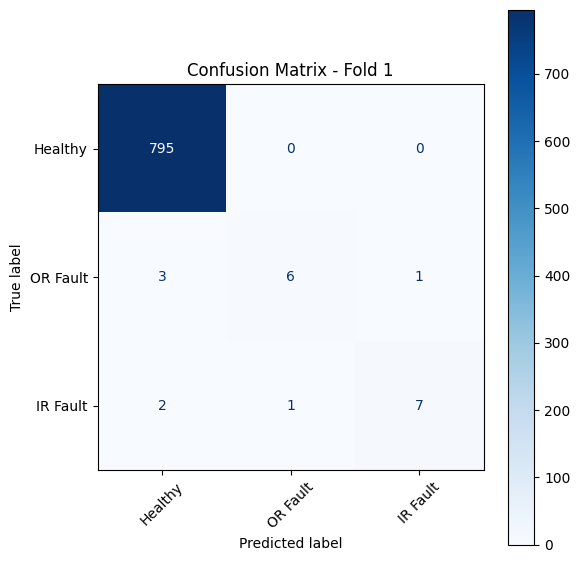

Saved confusion matrix for Fold 1 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/confusion_matrices/confusion_matrix_fold_1.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 200ms/step - accuracy: 0.9972 - loss: 0.0111 - val_accuracy: 0.9800 - val_loss: 0.0748
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.9952 - loss: 0.0178
Epoch 9: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 177ms/step - accuracy: 0.9952 - loss: 0.0177 - val_accuracy: 0.9585 - val_loss: 0.1156
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.9951 - loss: 0.0165
Epoch 10: val_accuracy improved from 0.98003 to 0.98925, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_2.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 201ms/step - accuracy: 0.9951 - loss: 0.0164 - val_accuracy: 0.9892 - val_loss: 0.0476
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9979 - loss: 0.0046
Epoch 11: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 244ms/step - accuracy: 0.9979 - loss: 0.0046 - val_accuracy: 0.9785 - val_loss: 0.1418
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step - accuracy: 0.9976 - loss: 0.0066
Epoch 12: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 176ms/step - accuracy: 0.9976 - loss: 0.0066 - val_accuracy: 0.8786 - val_loss: 0.3460
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.9980 - loss: 0.0060
Epoch 13: val_accuracy did not improve from 0.98925
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 163ms/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.8694 - val_loss: 0.2874
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.9930 - loss: 0.0148
Epoch 14: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.9956 - loss: 0.0129 - val_accuracy: 0.9908 - val_loss: 0.0452
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step - accuracy: 0.9998 - loss: 0.0032
Epoch 16: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 167ms/step - accuracy: 0.9998 - loss: 0.0032 - val_accuracy: 0.9892 - val_loss: 0.0527
Epoch 17/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.9995 - loss: 0.0020
Epoch 17: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 14s 174ms/step - accuracy: 0.9995 - loss: 0.0020 - val_accuracy: 0.9892 - val_loss: 0.0817
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 1.0000 - loss: 0.0016
Epoch 18: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 192ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.9908 - val_loss: 0.0458
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 1.0000 - loss: 6.9431e-04
Epoch 19: val_ac

82/82 ━━━━━━━━━━━━━━━━━━━━ 16s 189ms/step - accuracy: 1.0000 - loss: 6.9217e-04 - val_accuracy: 0.9923 - val_loss: 0.0340
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 1.0000 - loss: 5.8861e-04
Epoch 20: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 188ms/step - accuracy: 1.0000 - loss: 5.8549e-04 - val_accuracy: 0.9923 - val_loss: 0.0320
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 1.0000 - loss: 1.8940e-04
Epoch 21: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 177ms/step - accuracy: 1.0000 - loss: 1.8929e-04 - val_accuracy: 0.9923 - val_loss: 0.0334
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 1.0000 - loss: 2.3531e-04
Epoch 22: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 1.0000 - loss: 2.3398e-04 - val_accuracy: 0.9923 - val_loss: 0.0320
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 1.0000 - loss:

82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 179ms/step - accuracy: 1.0000 - loss: 1.1993e-04 - val_accuracy: 0.9939 - val_loss: 0.0307
Epoch 29/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - accuracy: 1.0000 - loss: 6.6117e-05
Epoch 29: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 157ms/step - accuracy: 1.0000 - loss: 6.6122e-05 - val_accuracy: 0.9939 - val_loss: 0.0312
Epoch 30/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 1.0000 - loss: 1.2705e-04
Epoch 30: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 1.0000 - loss: 1.2654e-04 - val_accuracy: 0.9923 - val_loss: 0.0352
Epoch 31/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 1.0000 - loss: 3.4437e-05
Epoch 31: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 154ms/step - accuracy: 1.0000 - loss: 3.4494e-05 - val_accuracy: 0.9923 - val_loss: 0.0371
Epoch 32/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 1.0000 - loss:

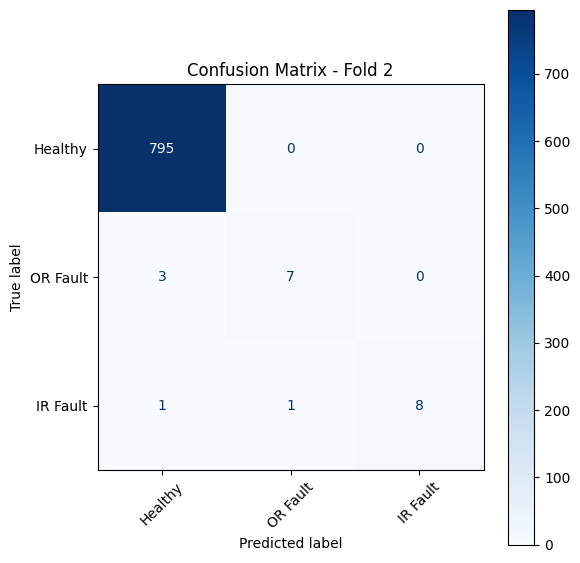

Saved confusion matrix for Fold 2 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/confusion_matrices/confusion_matrix_fold_2.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.9953 - loss: 0.0135 - val_accuracy: 0.9800 - val_loss: 0.1839
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9937 - loss: 0.0140
Epoch 9: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.9937 - loss: 0.0140 - val_accuracy: 0.9800 - val_loss: 0.2564
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9962 - loss: 0.0120
Epoch 10: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.9962 - loss: 0.0120 - val_accuracy: 0.9785 - val_loss: 0.2486
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9999 - loss: 0.0059
Epoch 11: val_accuracy improved from 0.98003 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.9999 - loss: 0.0059 - val_accuracy: 0.9877 - val_loss: 0.0710
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9995 - loss: 0.0034
Epoch 12: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.9995 - loss: 0.0034 - val_accuracy: 0.9846 - val_loss: 0.0636
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9981 - loss: 0.0050
Epoch 13: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.9981 - loss: 0.0050 - val_accuracy: 0.9570 - val_loss: 0.1232
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9999 - loss: 0.0031
Epoch 14: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.9999 - loss: 0.0031 - val_accuracy: 0.9846 - val_loss: 0.0784
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9976 - loss: 0.0066
Epoch 15: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 1.0000 - loss: 0.0010 - val_accuracy: 0.9892 - val_loss: 0.0716
Epoch 18/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 1.0000 - loss: 4.3899e-04
Epoch 18: val_accuracy improved from 0.98925 to 0.99232, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 1.0000 - loss: 4.3823e-04 - val_accuracy: 0.9923 - val_loss: 0.0593
Epoch 19/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 1.0000 - loss: 6.1007e-04
Epoch 19: val_accuracy did not improve from 0.99232
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 1.0000 - loss: 6.0713e-04 - val_accuracy: 0.9923 - val_loss: 0.0641
Epoch 20/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 1.0000 - loss: 3.1727e-04
Epoch 20: val_accuracy improved from 0.99232 to 0.99386, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_3.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 1.0000 - loss: 3.1856e-04 - val_accuracy: 0.9939 - val_loss: 0.0537
Epoch 21/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step - accuracy: 1.0000 - loss: 1.7316e-04
Epoch 21: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 1.0000 - loss: 1.7239e-04 - val_accuracy: 0.9923 - val_loss: 0.0540
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 1.0000 - loss: 4.1615e-04
Epoch 22: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 1.0000 - loss: 4.1311e-04 - val_accuracy: 0.9923 - val_loss: 0.0541
Epoch 23/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 1.0000 - loss: 3.3979e-04
Epoch 23: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 140ms/step - accuracy: 1.0000 - loss: 3.3876e-04 - val_accuracy: 0.9923 - val_loss: 0.0529
Epoch 24/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 1.0000 - loss:

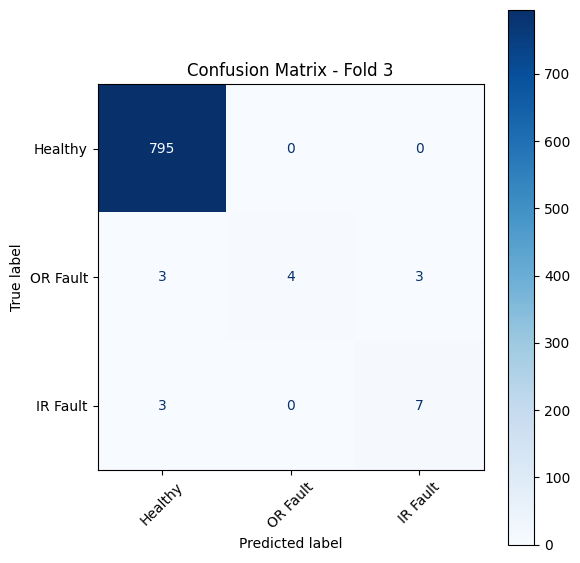

Saved confusion matrix for Fold 3 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/confusion_matrices/confusion_matrix_fold_3.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

Epoch 1/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9308 - loss: 0.1931
Epoch 1: val_accuracy improved from -inf to 0.01229, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 17s 176ms/step - accuracy: 0.9313 - loss: 0.1921 - val_accuracy: 0.0123 - val_loss: 1.0836
Epoch 2/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9736 - loss: 0.1069
Epoch 2: val_accuracy improved from 0.01229 to 0.97542, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 13s 153ms/step - accuracy: 0.9737 - loss: 0.1065 - val_accuracy: 0.9754 - val_loss: 0.1822
Epoch 3/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 0.9770 - loss: 0.0688
Epoch 3: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 0.9771 - loss: 0.0687 - val_accuracy: 0.9754 - val_loss: 0.1411
Epoch 4/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - accuracy: 0.9835 - loss: 0.0551
Epoch 4: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 150ms/step - accuracy: 0.9835 - loss: 0.0549 - val_accuracy: 0.9754 - val_loss: 0.2895
Epoch 5/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9896 - loss: 0.0332
Epoch 5: val_accuracy did not improve from 0.97542
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 0.9897 - loss: 0.0331 - val_accuracy: 0.9754 - val_loss: 0.2635
Epoch 6/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - accuracy: 0.9921 - loss: 0.0310
Epoch 6: val_accuracy did n

82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step - accuracy: 0.9960 - loss: 0.0150 - val_accuracy: 0.9800 - val_loss: 0.1500
Epoch 8/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 0.9959 - loss: 0.0158
Epoch 8: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 11s 141ms/step - accuracy: 0.9959 - loss: 0.0158 - val_accuracy: 0.9708 - val_loss: 0.1012
Epoch 9/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9864 - loss: 0.0326
Epoch 9: val_accuracy did not improve from 0.98003
82/82 ━━━━━━━━━━━━━━━━━━━━ 15s 187ms/step - accuracy: 0.9864 - loss: 0.0325 - val_accuracy: 0.9800 - val_loss: 0.0791
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.9935 - loss: 0.0222
Epoch 10: val_accuracy improved from 0.98003 to 0.99078, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_4.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - accuracy: 0.9935 - loss: 0.0221 - val_accuracy: 0.9908 - val_loss: 0.0356
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9975 - loss: 0.0057
Epoch 11: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.9975 - loss: 0.0057 - val_accuracy: 0.9800 - val_loss: 0.0983
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9995 - loss: 0.0039
Epoch 12: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 142ms/step - accuracy: 0.9995 - loss: 0.0039 - val_accuracy: 0.9754 - val_loss: 0.2295
Epoch 13/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.9981 - loss: 0.0066
Epoch 13: val_accuracy did not improve from 0.99078
82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - accuracy: 0.9981 - loss: 0.0065 - val_accuracy: 0.9877 - val_loss: 0.0581
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step - accuracy: 0.9993 - loss: 0.0040
Epoch 14: val_accuracy 

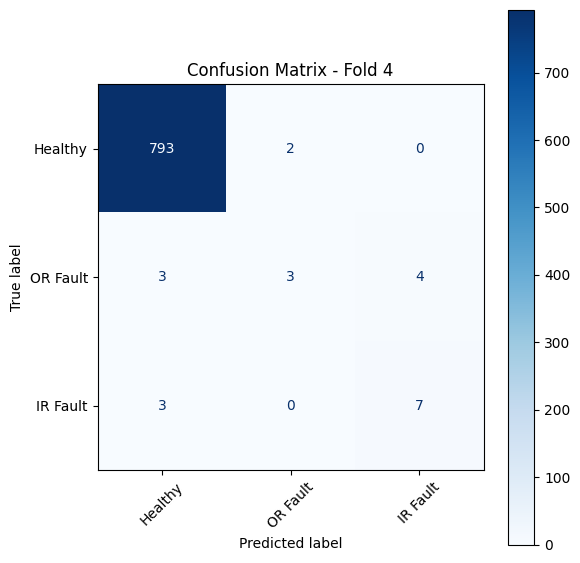

Saved confusion matrix for Fold 4 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/confusion_matrices/confusion_matrix_fold_4.png


/Users/Gayathri/pyenvs/tf-env/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 96, 96, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 96, 96, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 48, 48, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 48, 48, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,563 (416.26 KB)

...

82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - accuracy: 0.9968 - loss: 0.0133 - val_accuracy: 0.9785 - val_loss: 0.0675
Epoch 10/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9945 - loss: 0.0148
Epoch 10: val_accuracy improved from 0.97849 to 0.98771, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - accuracy: 0.9945 - loss: 0.0147 - val_accuracy: 0.9877 - val_loss: 0.0355
Epoch 11/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step - accuracy: 1.0000 - loss: 0.0047
Epoch 11: val_accuracy did not improve from 0.98771
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 0.9539 - val_loss: 0.1525
Epoch 12/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9999 - loss: 0.0030
Epoch 12: val_accuracy improved from 0.98771 to 0.99386, saving model to Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_5.h5


82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 144ms/step - accuracy: 0.9999 - loss: 0.0030 - val_accuracy: 0.9939 - val_loss: 0.0416
Epoch 13/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.9989 - loss: 0.0043
Epoch 13: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 143ms/step - accuracy: 0.9989 - loss: 0.0043 - val_accuracy: 0.9877 - val_loss: 0.0569
Epoch 14/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - accuracy: 1.0000 - loss: 0.0028
Epoch 14: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 141ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.9939 - val_loss: 0.0417
Epoch 15/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss: 0.0015
Epoch 15: val_accuracy did not improve from 0.99386
82/82 ━━━━━━━━━━━━━━━━━━━━ 12s 149ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.9939 - val_loss: 0.0437
Epoch 16/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.9993 - loss: 0.0025
Epoch 16: val_accura

82/82 ━━━━━━━━━━━━━━━━━━━━ 8s 91ms/step - accuracy: 1.0000 - loss: 2.4310e-04 - val_accuracy: 0.9954 - val_loss: 0.0448
Epoch 21/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 3.1258e-04
Epoch 21: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - accuracy: 1.0000 - loss: 3.0893e-04 - val_accuracy: 0.9954 - val_loss: 0.0415
Epoch 22/200
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 1.8340e-04
Epoch 22: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 88ms/step - accuracy: 1.0000 - loss: 1.8256e-04 - val_accuracy: 0.9954 - val_loss: 0.0405
Epoch 23/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 1.0000 - loss: 8.6979e-05
Epoch 23: val_accuracy did not improve from 0.99539
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 86ms/step - accuracy: 1.0000 - loss: 8.6694e-05 - val_accuracy: 0.9954 - val_loss: 0.0387
Epoch 24/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 6.9563e-05


82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 85ms/step - accuracy: 1.0000 - loss: 3.7052e-05 - val_accuracy: 0.9969 - val_loss: 0.0355
Epoch 42/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 1.7654e-05
Epoch 42: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 1.0000 - loss: 1.7687e-05 - val_accuracy: 0.9954 - val_loss: 0.0425
Epoch 43/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 1.0000 - loss: 1.4436e-05
Epoch 43: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 82ms/step - accuracy: 1.0000 - loss: 1.4339e-05 - val_accuracy: 0.9954 - val_loss: 0.0496
Epoch 44/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 1.0000 - loss: 1.7642e-05
Epoch 44: val_accuracy did not improve from 0.99693
82/82 ━━━━━━━━━━━━━━━━━━━━ 7s 90ms/step - accuracy: 1.0000 - loss: 1.7617e-05 - val_accuracy: 0.9954 - val_loss: 0.0484
Epoch 45/200
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step - accuracy: 1.0000 - loss: 1.8512e-05


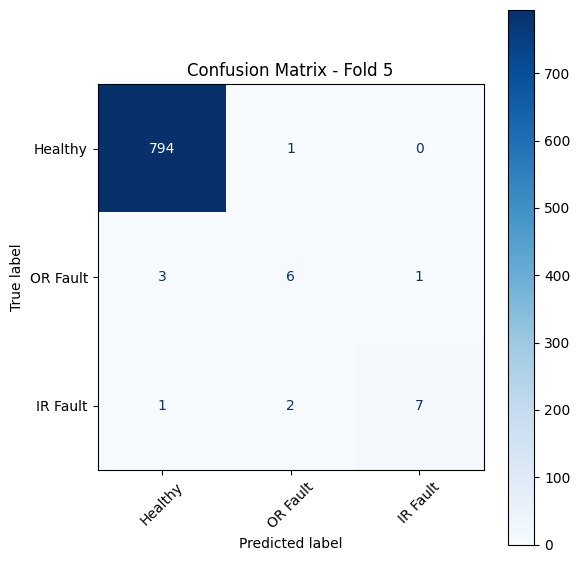

Saved confusion matrix for Fold 5 at: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/confusion_matrices/confusion_matrix_fold_5.png
Total Computation Time: 6488.93 seconds (108.15 minutes)


In [12]:
# Training with k-fold validation
kSplits = 5
accuracy_2D = []
precision_2D = []
recall_2D = []
f1_2D = []
log_loss_2D = []
balanced_accuracy_2D = []
precision_2D_macro = []
recall_2D_macro = []
f1_2D_macro = []
accuracy_2D_test = []
precision_2D_test = []
recall_2D_test = []
log_loss_2D_test = []
f1_2D_test = []
precision_2D_test_macro = []
recall_2D_test_macro = []
f1_2D_test_macro = []
balanced_accuracy_2D_test = []
# accuracy_val = []

condition_map = {
    0: "Healthy",
    1: "OR Fault",
    2: "IR Fault"
}

early_stopping = EarlyStopping(monitor='val_accuracy', patience=50, restore_best_weights=True)
start_time = time.time()
y_labels = np.argmax(y_train_positional_split, axis=1)

kfold = StratifiedKFold(n_splits=kSplits, random_state=32, shuffle=True)

for fold, (train_idx, test_idx) in enumerate(kfold.split(X_2D_train, y_labels)):

    Classification_2D = CNN_2D()

    checkpoint_filepath = os.path.join(foldername, f"best_model_fold_{fold+1}.h5")
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_filepath,
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1,
        mode='max'
    )

    Classification_2D.model.fit(X_2D_train[train_idx], y_train_positional_split[train_idx],
                                validation_data=(X_2D_train[test_idx], y_train_positional_split[test_idx]),
                                epochs=200, callbacks=[early_stopping, checkpoint], verbose=1)

    print(f"Best model for Fold {fold+1} saved to: {checkpoint_filepath}")

    # Train set metrics
    y_pred_proba_train = Classification_2D.model.predict(X_2D_train)
    y_pred_train = np.argmax(y_pred_proba_train, axis=1)
    y_true_train = np.argmax(y_train_positional_split, axis=1)

    accuracy_2D.append(accuracy_score(y_true_train, y_pred_train))
    precision_2D.append(precision_score(y_true_train, y_pred_train, average='weighted'))
    recall_2D.append(recall_score(y_true_train, y_pred_train, average='weighted'))
    f1_2D.append(f1_score(y_true_train, y_pred_train, average='weighted'))
    log_loss_2D.append(log_loss(y_true_train, y_pred_proba_train))
    balanced_accuracy_2D.append(balanced_accuracy_score(y_true_train, y_pred_train))
    precision_2D_macro.append(precision_score(y_true_train, y_pred_train, average='macro'))
    recall_2D_macro.append(recall_score(y_true_train, y_pred_train, average='macro'))
    f1_2D_macro.append(f1_score(y_true_train, y_pred_train, average='macro'))

    # Test set metrics
    y_pred_proba_test = Classification_2D.model.predict(X_2D_test)
    y_pred_test = np.argmax(y_pred_proba_test, axis=1)
    y_true_test = np.argmax(y_test_positional_split, axis=1)

    # Confusion matrix
    cm = confusion_matrix(y_true_test, y_pred_test)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[condition_map[i] for i in range(3)])
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap='Blues', ax=ax, xticks_rotation=45)
    plt.title(f'Confusion Matrix - Fold {fold + 1}')
    plt.grid(False)
    plt.tight_layout()

    # Save confusion matrix
    save_dir = os.path.join(foldername, "confusion_matrices")
    os.makedirs(save_dir, exist_ok=True)
    save_path = os.path.join(save_dir, f"confusion_matrix_fold_{fold + 1}.png")
    plt.savefig(save_path, dpi=300)
    plt.show()
    print(f"Saved confusion matrix for Fold {fold + 1} at: {save_path}")

    # accuracy_val.append(accuracy_score(X_2D_train[test_idx], y_train_positional_split[test_idx]))
    accuracy_2D_test.append(accuracy_score(y_true_test, y_pred_test))
    precision_2D_test.append(precision_score(y_true_test, y_pred_test, average='weighted'))
    recall_2D_test.append(recall_score(y_true_test, y_pred_test, average='weighted'))
    f1_2D_test.append(f1_score(y_true_test, y_pred_test, average='weighted'))
    precision_2D_test_macro.append(precision_score(y_true_test, y_pred_test, average='macro'))
    recall_2D_test_macro.append(recall_score(y_true_test, y_pred_test, average='macro'))
    f1_2D_test_macro.append(f1_score(y_true_test, y_pred_test, average='macro'))
    log_loss_2D_test.append(log_loss(y_true_test, y_pred_proba_test))
    balanced_accuracy_2D_test.append(balanced_accuracy_score(y_true_test, y_pred_test))

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Total Computation Time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [13]:
# Aggregated metrics
CNN_2D_train_accuracy = np.mean(accuracy_2D) * 100
CNN_2D_test_accuracy = np.mean(accuracy_2D_test) * 100
CNN_2D_train_precision = np.mean(precision_2D) * 100
CNN_2D_test_precision = np.mean(precision_2D_test) * 100
CNN_2D_train_recall = np.mean(recall_2D) * 100
CNN_2D_test_recall = np.mean(recall_2D_test) * 100
CNN_2D_train_f1 = np.mean(f1_2D) * 100
CNN_2D_test_f1 = np.mean(f1_2D_test) * 100
CNN_2D_train_precision_macro = np.mean(precision_2D_macro) * 100
CNN_2D_train_recall_macro = np.mean(recall_2D_macro) * 100
CNN_2D_train_f1_macro = np.mean(f1_2D_macro) * 100
CNN_2D_test_precision_macro = np.mean(precision_2D_test_macro) * 100
CNN_2D_test_recall_macro = np.mean(recall_2D_test_macro) * 100
CNN_2D_test_f1_macro = np.mean(f1_2D_test_macro) * 100
CNN_2D_train_log_loss = np.mean(log_loss_2D)
CNN_2D_test_log_loss = np.mean(log_loss_2D_test)
CNN_2D_train_balanced_accuracy = np.mean(balanced_accuracy_2D) * 100
CNN_2D_test_balanced_accuracy = np.mean(balanced_accuracy_2D_test) * 100
# CNN_2D_val_accuracy = np.mean(accuracy_val) * 100

# Print metrics
print(f"Train Accuracy: {CNN_2D_train_accuracy:.2f}%")
print(f"Test Accuracy: {CNN_2D_test_accuracy:.2f}%")
print(f"Train Precision: {CNN_2D_train_precision:.2f}%")
print(f"Test Precision: {CNN_2D_test_precision:.2f}%")
print(f"Train Recall: {CNN_2D_train_recall:.2f}%")
print(f"Test Recall: {CNN_2D_test_recall:.2f}%")
print(f"Train F1: {CNN_2D_train_f1:.2f}%")
print(f"Test F1: {CNN_2D_test_f1:.2f}%")
print(f"Train Log Loss: {CNN_2D_train_log_loss:.4f}")
print(f"Test Log Loss: {CNN_2D_test_log_loss:.4f}")
print(f"Train Balanced Accuracy: {CNN_2D_train_balanced_accuracy:.2f}%")
print(f"Test Balanced Accuracy: {CNN_2D_test_balanced_accuracy:.2f}%")

print(f"Train Precision (Macro): {CNN_2D_train_precision_macro:.2f}%")
print(f"Train Recall (Macro): {CNN_2D_train_recall_macro:.2f}%")
print(f"Train F1 Score (Macro): {CNN_2D_train_f1_macro:.2f}%")

print(f"Test Precision (Macro): {CNN_2D_test_precision_macro:.2f}%")
print(f"Test Recall (Macro): {CNN_2D_test_recall_macro:.2f}%")
print(f"Test F1 Score (Macro): {CNN_2D_test_f1_macro:.2f}%")

# print(f"CNN_2D_val_accuracy: {CNN_2D_val_accuracy:.2f}%")


Train Accuracy: 99.80%
Test Accuracy: 98.99%
Train Precision: 99.80%
Test Precision: 98.92%
Train Recall: 99.80%
Test Recall: 98.99%
Train F1: 99.80%
Test F1: 98.90%
Train Log Loss: 0.0103
Test Log Loss: 0.0579
Train Balanced Accuracy: 95.16%
Test Balanced Accuracy: 74.64%
Train Precision (Macro): 97.93%
Train Recall (Macro): 95.16%
Train F1 Score (Macro): 96.43%
Test Precision (Macro): 87.03%
Test Recall (Macro): 74.64%
Test F1 Score (Macro): 79.20%


102/102 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step


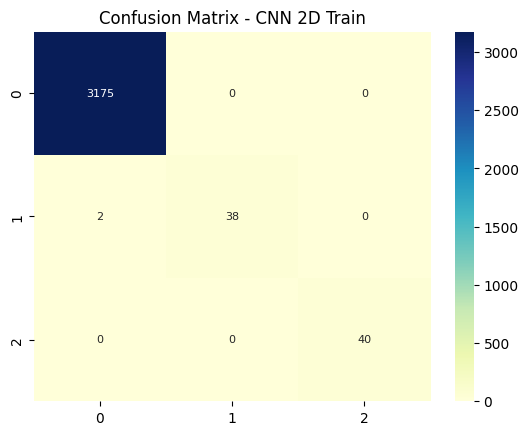

26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


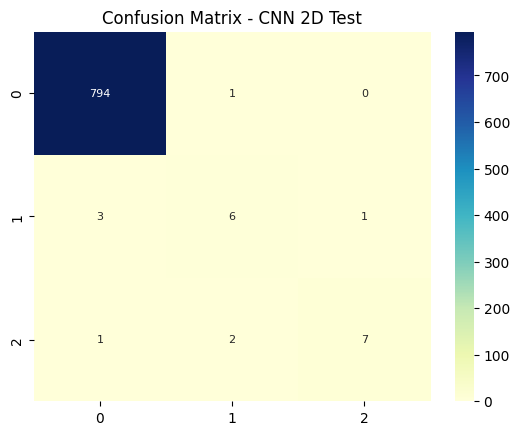

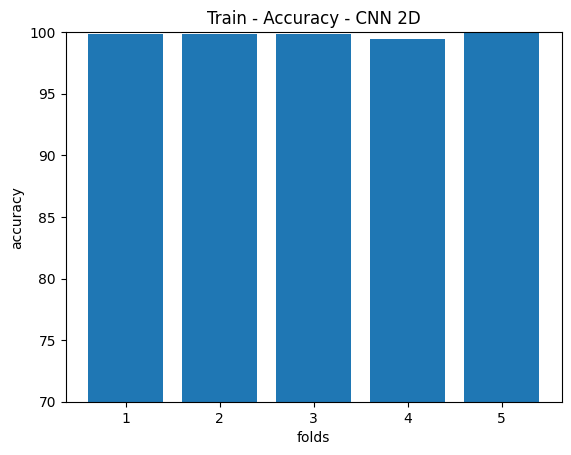

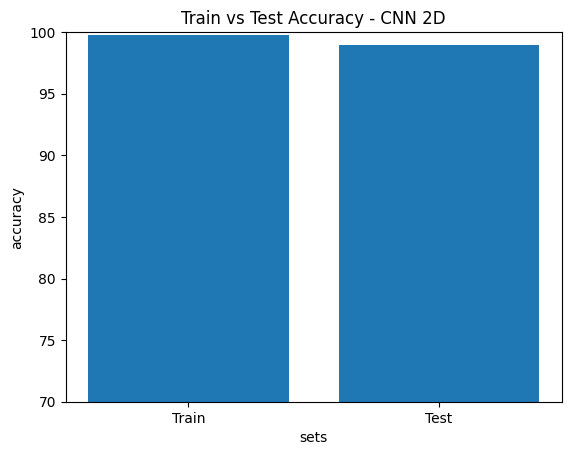

In [14]:
# Confusion Matrix Calculation
def ConfusionMatrix(Model, X, y):
    y_pred_proba = Model.model.predict(X)
    y_pred = np.argmax(y_pred_proba, axis=1)
    y_true = np.argmax(y, axis=1)
    return confusion_matrix(y_true, y_pred)

# Plot results - CNN 2D
plt.figure(1)
plt.title('Confusion Matrix - CNN 2D Train')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_train, y_train_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(2)
plt.title('Confusion Matrix - CNN 2D Test')
sns.heatmap(ConfusionMatrix(Classification_2D, X_2D_test, y_test_positional_split),
            annot=True, fmt='d', annot_kws={"fontsize": 8}, cmap="YlGnBu")
plt.show()

plt.figure(3)
plt.title('Train - Accuracy - CNN 2D')
plt.bar(np.arange(1, kSplits + 1), [i * 100 for i in accuracy_2D])
plt.ylabel('accuracy')
plt.xlabel('folds')
plt.ylim([70, 100])
plt.show()

plt.figure(4)
plt.title('Train vs Test Accuracy - CNN 2D')
plt.bar([1, 2], [CNN_2D_train_accuracy, CNN_2D_test_accuracy])
plt.ylabel('accuracy')
plt.xlabel('sets')
plt.xticks([1, 2], ['Train', 'Test'])
plt.ylim([70, 100])
plt.show()



Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_1.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


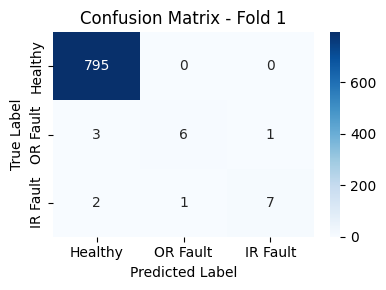


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_2.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step


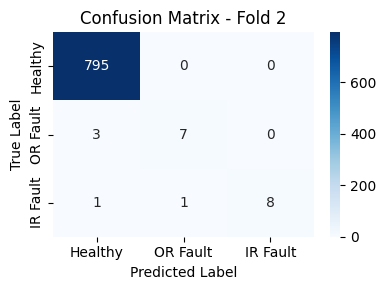


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_3.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step


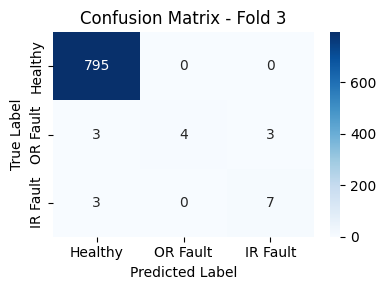


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_4.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step


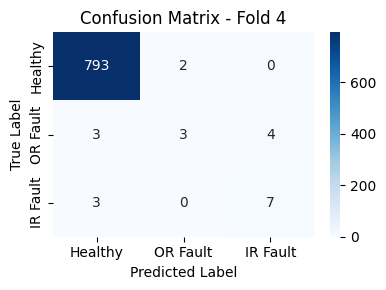


Evaluating model: Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Spectrogram/best_model_fold_5.h5
102/102 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step


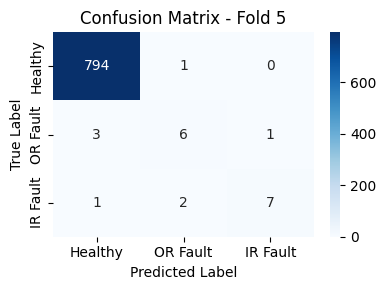


 Test Metrics Summary (Same Test Set Across All Models):


,Fold,Test Accuracy (%),Test Precision (%),Test Recall (%),Test F1-score (%),Test Precision (Macro) (%),Test Recall (Macro) (%),Test F1-score (Macro) (%),Test Log Loss,Test Balanced Accuracy (%),Train Accuracy (%),Train Precision (%),Train Recall (%),Train F1-score (%),Train Precision (Macro) (%),Train Recall (Macro) (%),Train F1-score (Macro) (%),Train Log Loss,Train Balanced Accuracy (%)
0,1,99.14,99.06,99.14,99.06,90.86,76.67,82.68,0.05,76.67,99.85,99.84,99.85,99.84,99.08,95.83,97.41,0.01,95.83
1,2,99.39,99.36,99.39,99.35,95.67,83.33,88.81,0.05,83.33,99.88,99.88,99.88,99.88,99.14,96.67,97.85,0.01,96.67
2,3,98.90,98.90,98.90,98.74,89.75,70.00,75.59,0.07,70.00,99.88,99.88,99.88,99.88,99.96,96.67,98.26,0.01,96.67
3,4,98.53,98.33,98.53,98.37,74.30,66.58,68.72,0.05,66.58,99.48,99.47,99.48,99.46,91.50,88.30,89.50,0.02,88.30
4,5,99.02,98.95,99.02,98.97,84.56,76.62,80.21,0.06,76.62,99.94,99.94,99.94,99.94,99.98,98.33,99.13,0.01,98.33


In [25]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    balanced_accuracy_score, log_loss, confusion_matrix
)
import seaborn as sns
import matplotlib.pyplot as plt

# Set paths
# foldername = "Paderborn_results/Paderborn-imbalance-2D-TimeSplit-Scalogram-2layer-CS"
num_folds = 5  # Assuming models are: best_model_fold_1.h5 to _5.h5

# Use these test variables from your data pipeline
# Already loaded:
# X_test_split, y_test_positional_split

# Flatten labels
y_true = np.argmax(y_test_positional_split, axis=1)
y_train_true = np.argmax(y_train_positional_split, axis=1)

# Containers
folds = []
accuracy_test = []
precision_test = []
recall_test = []
f1_test = []
precision_macro_test = []
recall_macro_test = []
f1_macro_test = []
log_loss_test = []
balanced_acc_test = []

accuracy_train = []
precision_train = []
recall_train = []
f1_train = []
precision_macro_train = []
recall_macro_train = []
f1_macro_train = []
log_loss_train = []
balanced_acc_train = []

# Loop through models
for fold in range(1, num_folds + 1):
    model_path = os.path.join(foldername, f"best_model_fold_{fold}.h5")
    print(f"\nEvaluating model: {model_path}")

    model = load_model(model_path)
      #train metrics
    y_train_pred_proba = model.predict(X_train_split)
    y_train_pred = np.argmax(y_train_pred_proba, axis=1)
    
    #test metrics
    y_pred_proba = model.predict(X_test_split, verbose=0)
    y_pred = np.argmax(y_pred_proba, axis=1)

    folds.append(fold)
    accuracy_test.append(accuracy_score(y_true, y_pred) * 100)
    precision_test.append(precision_score(y_true, y_pred, average='weighted') * 100)
    recall_test.append(recall_score(y_true, y_pred, average='weighted') * 100)
    f1_test.append(f1_score(y_true, y_pred, average='weighted') * 100)

    precision_macro_test.append(precision_score(y_true, y_pred, average='macro') * 100)
    recall_macro_test.append(recall_score(y_true, y_pred, average='macro') * 100)
    f1_macro_test.append(f1_score(y_true, y_pred, average='macro') * 100)

    log_loss_test.append(log_loss(y_true, y_pred_proba))
    balanced_acc_test.append(balanced_accuracy_score(y_true, y_pred) * 100)

    accuracy_train.append(accuracy_score(y_train_true, y_train_pred) * 100)
    precision_train.append(precision_score(y_train_true, y_train_pred, average='weighted') * 100)
    recall_train.append(recall_score(y_train_true, y_train_pred, average='weighted') * 100)
    f1_train.append(f1_score(y_train_true, y_train_pred,average='weighted') * 100)

    precision_macro_train.append(precision_score(y_train_true, y_train_pred, average='macro') * 100)
    recall_macro_train.append(recall_score(y_train_true, y_train_pred,average='macro') * 100)
    f1_macro_train.append(f1_score(y_train_true, y_train_pred,average='macro') * 100)

    log_loss_train.append(log_loss(y_train_true, y_train_pred_proba))
    balanced_acc_train.append(balanced_accuracy_score(y_train_true, y_train_pred) * 100)

    class_names = ['Healthy', 'OR Fault', 'IR Fault']
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - Fold {fold}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()
    

# Create and print metrics DataFrame
metrics_df = pd.DataFrame({
    'Fold': folds,
    'Test Accuracy (%)': accuracy_test,
    'Test Precision (%)': precision_test,
    'Test Recall (%)': recall_test,
    'Test F1-score (%)': f1_test,
    'Test Precision (Macro) (%)': precision_macro_test,
    'Test Recall (Macro) (%)': recall_macro_test,
    'Test F1-score (Macro) (%)': f1_macro_test,
    'Test Log Loss': log_loss_test,
    'Test Balanced Accuracy (%)': balanced_acc_test,
    'Train Accuracy (%)': accuracy_train,
    'Train Precision (%)': precision_train,
    'Train Recall (%)': recall_train,
    'Train F1-score (%)': f1_train,
    'Train Precision (Macro) (%)': precision_macro_train,
    'Train Recall (Macro) (%)': recall_macro_train,
    'Train F1-score (Macro) (%)': f1_macro_train,
    'Train Log Loss': log_loss_train,
    'Train Balanced Accuracy (%)': balanced_acc_train
}).round(2)

print("\n Test Metrics Summary (Same Test Set Across All Models):")
metrics_df
